In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme(style="whitegrid")


from sklearn.model_selection import(
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    cross_val_predict,
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve


from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report

RANDOM_SEED = 42

## EDA

In [2]:
df = pd.read_csv('historical_data.csv')

df.head()

,id,day,event_type,category,region,device,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min,is_suspicious
0,0,8,ad_post,other,urban,android,38.4,2,1,1,594.16,3,91,0,1,0,2.3,0
1,1,4,ad_post,fashion,urban,android,20.0,1,0,1,134.47,2,150,0,0,0,13.6,0
2,2,4,ad_post,other,metro,ios,46.7,3,1,1,198.52,3,72,0,0,0,4.2,0
3,3,3,ad_post,furniture,metro,android,44.3,3,1,2,141.20,3,0,0,0,0,19.8,0
4,4,1,ad_post,electronics,metro,web,211.2,5,0,0,81.39,3,9,0,0,1,23.3,0


In [3]:
print("Antal rader:", df.shape[0])
print("Antal kolumner:", df.shape[1])

print("\nDatasetets datatyper:")
print("------------------------------")
print(df.dtypes)

Antal rader: 12000
Antal kolumner: 18

Datasetets datatyper:
------------------------------
id                              int64
day                             int64
event_type                        str
category                          str
region                            str
device                            str
account_age_days              float64
num_prev_listings               int64
prev_reports_30d                int64
verification_level              int64
price                         float64
num_images                      int64
message_length                  int64
contains_off_platform           int64
urgency_words                   int64
payment_attempt                 int64
time_to_first_response_min    float64
is_suspicious                   int64
dtype: object


In [4]:
print("\nSaknade värden per kolumn:")
print("------------------------------")
print(df.isna().sum())


Saknade värden per kolumn:
------------------------------
id                              0
day                             0
event_type                      0
category                        0
region                        340
device                          0
account_age_days                0
num_prev_listings               0
prev_reports_30d                0
verification_level              0
price                         818
num_images                      0
message_length                  0
contains_off_platform           0
urgency_words                   0
payment_attempt                 0
time_to_first_response_min    590
is_suspicious                   0
dtype: int64


In [5]:
df = df.drop(columns=['id'])

df.describe().T

,count,mean,std,min,25%,50%,75%,max
day,12000.0,7.482667,4.032520,1.00,4.000,7.000,11.000,14.00
account_age_days,12000.0,99.632567,112.903541,2.20,36.300,66.600,120.700,2741.70
num_prev_listings,12000.0,3.027750,1.766467,0.00,2.000,3.000,4.000,12.00
prev_reports_30d,12000.0,0.151500,0.386083,0.00,0.000,0.000,0.000,3.00
verification_level,12000.0,0.710167,0.719171,0.00,0.000,1.000,1.000,2.00
price,11182.0,207.348603,196.226023,7.67,86.195,149.225,256.795,2743.08
num_images,12000.0,2.870417,1.766886,0.00,2.000,3.000,4.000,10.00
message_length,12000.0,111.154417,66.396885,0.00,63.000,108.000,155.000,416.00
contains_off_platform,12000.0,0.072833,0.259874,0.00,0.000,0.000,0.000,1.00
urgency_words,12000.0,0.099083,0.298786,0.00,0.000,0.000,0.000,1.00


In [6]:
print("Target-fördelning:")
print(df["is_suspicious"].value_counts())

print("\nProcentuell fördelning:")
print(df["is_suspicious"].value_counts(normalize=True) * 100)

Target-fördelning:
is_suspicious
0    10776
1     1224
Name: count, dtype: int64

Procentuell fördelning:
is_suspicious
0    89.8
1    10.2
Name: proportion, dtype: float64


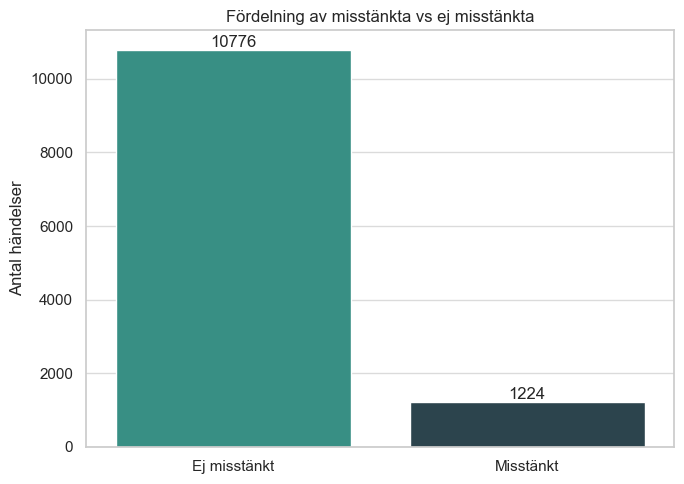

In [9]:
counts = df["is_suspicious"].value_counts(normalize=True) * 100

plt.figure(figsize=(7,5))
ax = sns.countplot(x="is_suspicious", hue="is_suspicious", data=df, palette=["#2a9d8f", "#264653"], legend=False)
plt.title("Fördelning av misstänkta vs ej misstänkta")
plt.xlabel("")
plt.ylabel("Antal händelser")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Ej misstänkt", "Misstänkt"])

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.grid(True, axis="y", alpha=0.7)
plt.tight_layout()
plt.show()


Datan i datasetet är obalanserad. Endast cirka 10 % av händelserna är misstänkta. 

In [10]:
numeric_cols = df.select_dtypes(include=np.number)

correlations = numeric_cols.corr()["is_suspicious"].sort_values(ascending=False)

top_corr = correlations.drop("is_suspicious")

top_corr = top_corr.reindex(top_corr.abs().sort_values(ascending=False).index)
top_5 = top_corr.head(5)

print("Korrelation med is_suspicious:")
print("----------------------------------")
print(top_5)

Korrelation med is_suspicious:
----------------------------------
contains_off_platform    0.141828
prev_reports_30d         0.130920
account_age_days        -0.103146
verification_level      -0.100409
urgency_words            0.087295
Name: is_suspicious, dtype: float64


C:\Users\magda\AppData\Local\Temp\ipykernel_9888\3007845219.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


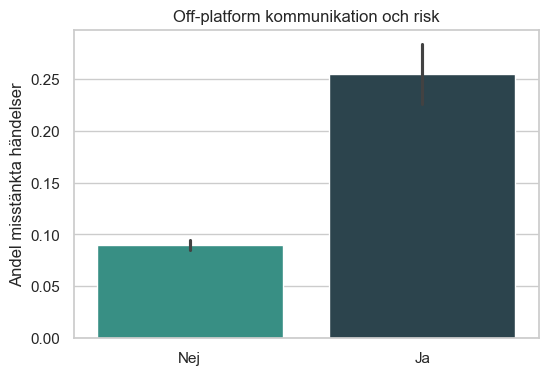

In [14]:
plt.figure(figsize=(6,4))

sns.barplot(
    x="contains_off_platform",
    y=df["is_suspicious"],
    data=df,
    palette=["#2a9d8f", "#264653"]
)

plt.title("Off-platform kommunikation och risk")
plt.xlabel("")
plt.ylabel("Andel misstänkta händelser")

plt.xticks([0,1], ["Nej", "Ja"])

plt.show()


När användare försöker flytta kommunikationen utanför plattformen ökar andelen misstänkta fall från cirka 10 % till ungefär 25 %.  
Detta tyder på att off-platform kommunikation är en stark risksignal och kan vara en viktig indikator i ett flaggningssystem.

C:\Users\magda\AppData\Local\Temp\ipykernel_9888\698570549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


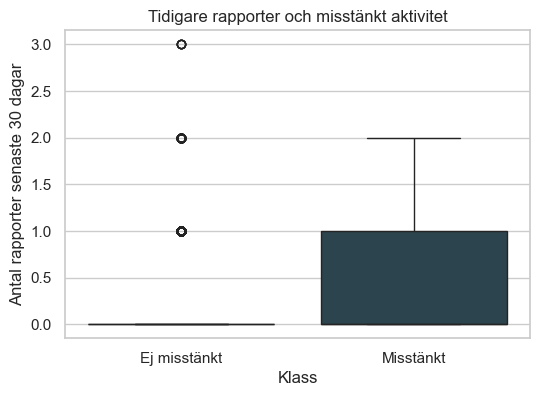

In [16]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x=df["is_suspicious"],
    y="prev_reports_30d",
    data=df,
    palette=["#2a9d8f", "#264653"]
)

plt.title("Tidigare rapporter och misstänkt aktivitet")
plt.xlabel("Klass")
plt.ylabel("Antal rapporter senaste 30 dagar")

plt.xticks([0,1], ["Ej misstänkt", "Misstänkt"])

plt.show()


Användare som klassificeras som misstänkta har oftare tidigare rapporter under de senaste 30 dagarna.  
För ej misstänkta fall ligger antalet rapporter nästan alltid på 0, medan misstänkta fall visar större variation och fler tidigare rapporter.  
Detta tyder på att även historik av tidigare rapporter kan vara en stor riskfaktor.

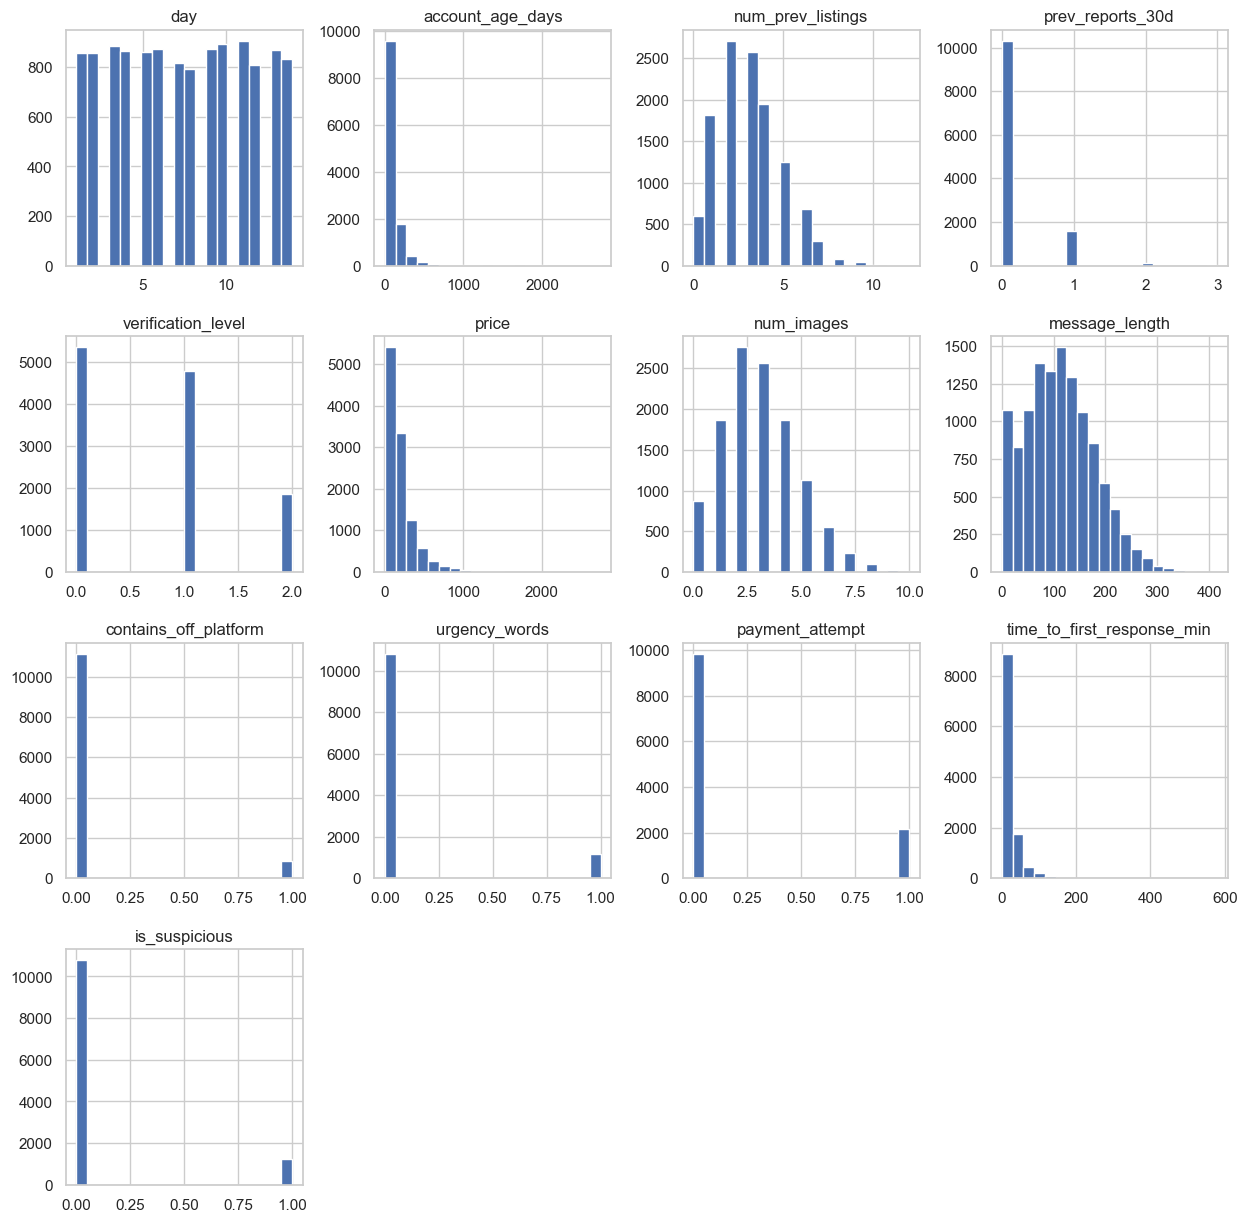

In [15]:
df.hist(figsize=(15,15), bins=20)
plt.show()

Split data

In [ ]:


X = df.drop(columns=["is_suspicious"])
y = df["is_suspicious"]


# Använd för K-fold eller cross validation
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state= RANDOM_SEED,
    stratify=y
)

# Använd om inte K-fold eller cross validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state= RANDOM_SEED,
    stratify= y_train
)

In [ ]:
X.columns

Pipeline

In [ ]:
num_cols = ['day',
            'account_age_days',
            'num_prev_listings',
            'prev_reports_30d',
            'verification_level',
            'price', 'num_images',
            'message_length',
            'contains_off_platform',
            'urgency_words',
            'payment_attempt',
            'time_to_first_response_min'
            ]
cat_cols = ['event_type', 'category', 'region', 'device']

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])



preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

def make_model(model):
    return Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])

Inställningar modeller

In [ ]:
log_reg = LogisticRegression(max_iter=200, class_weight="balanced")
rf = RandomForestClassifier(max_depth=5, random_state=RANDOM_SEED, n_jobs=-1, class_weight="balanced_subsample")
dt = DecisionTreeClassifier(random_state=RANDOM_SEED, class_weight="balanced")
gb = GradientBoostingClassifier(random_state=RANDOM_SEED)
model_dummy = DummyClassifier(strategy="stratified")

## Cross Validation

In [ ]:
model_lr = make_model(log_reg)
model_rf = make_model(rf)
model_dt = make_model(dt)
model_gb = make_model(gb)
model_dummy = make_model(model_dummy)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = "roc_auc"

In [ ]:
models = {
    "Dummy": model_dummy,
    "LogisticRegression": model_lr,
    "RandomForestClassifier": model_rf,
    "DecisionTree": model_dt,
    "GradientBoosting": model_gb
}


baseline_rows = []

for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=SCORING)
    baseline_rows.append({"model": name, "mean": scores.mean(), "std": scores.std()})

baseline_table = pd.DataFrame(baseline_rows).sort_values("mean", ascending=False)
baseline_table

In [ ]:
top2_models = baseline_table["model"].head(2).tolist()
print("top-2 models", top2_models)

## GridSearch Logistic Regression

In [ ]:
param_lr = {
    "model__C": [0.0001, 0.001, 0.01, 0.1, 1, 10],
    "model__penalty": ["l2"],
    "model__solver": ["liblinear"]
}

In [ ]:
grid_lr = GridSearchCV(
    estimator=model_lr,
    param_grid=param_lr,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1,
    verbose=2
)

grid_lr.fit(X_train, y_train)

## GridSearch RandomForest

In [ ]:
param_rf = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [None, 8, 12],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [4, 6, 8],
    "model__max_features": ["sqrt", "log2"]
}

In [ ]:
grid_rf = GridSearchCV(
    estimator=model_rf,
    param_grid=param_rf,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)

In [ ]:

print(grid_lr.best_score_)
print(grid_rf.best_score_)

if grid_lr.best_score_ > grid_rf.best_score_:
    print("LogisticRegression is the winner")
else:
    print("RandomForest is the winner")

best_model = grid_lr if grid_lr.best_score_ > grid_rf.best_score_ else grid_rf


vår baseline AP är 0.102 och vi fick 0.293 detta betyder att våran model är tre gånger bättre än slumpen